VotingClassifier

In [ ]:
# import xgboost

In [ ]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [ ]:
#import libraries
#data handel 
import numpy as np
import pandas as pd
# visualization 

import matplotlib.pyplot as plt
import seaborn as  sns

#dataset 
from sklearn.datasets import load_breast_cancer

# preproceesing 

from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

#model
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier



 
# evalution 

from sklearn.metrics import (accuracy_score , classification_report ,confusion_matrix,ConfusionMatrixDisplay)

# warning 

import warnings
warnings.filterwarnings("ignore")


# hyper parameter tunning 
from sklearn.model_selection import GridSearchCV 


In [ ]:
data = load_breast_cancer()

df = pd.DataFrame(data= data.data ,
                  columns= data.feature_names)
df["target"] =  data.target

print(df.head())

   mean radius  mean texture  ...  worst fractal dimension  target
0        17.99         10.38  ...                  0.11890       0
1        20.57         17.77  ...                  0.08902       0
2        19.69         21.25  ...                  0.08758       0
3        11.42         20.38  ...                  0.17300       0
4        20.29         14.34  ...                  0.07678       0

[5 rows x 31 columns]


In [ ]:
df.shape
df.isnull().mean()
df.duplicated().mean()


np.float64(0.0)

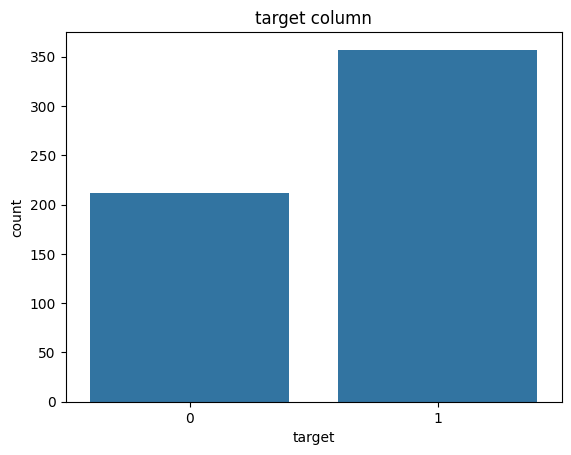

In [ ]:
sns.countplot(data= df , x="target")
plt.title("target column")
plt.show()

In [ ]:

X =  df.drop("target", axis=1)
y =  df["target"]

X_train , X_test , y_train , y_test = train_test_split(
    X,y , test_size=0.2 , random_state= 42 
)

print(X_train)

     mean radius  mean texture  ...  worst symmetry  worst fractal dimension
68         9.029         17.33  ...          0.4228                  0.11750
181       21.090         26.57  ...          0.4098                  0.12840
63         9.173         13.86  ...          0.3282                  0.08490
248       10.650         25.22  ...          0.3409                  0.08147
60        10.170         14.88  ...          0.3557                  0.08020
..           ...           ...  ...             ...                      ...
71         8.888         14.64  ...          0.2254                  0.10840
106       11.640         18.33  ...          0.2806                  0.09097
270       14.290         16.82  ...          0.2458                  0.06120
435       13.980         19.62  ...          0.3179                  0.10550
102       12.180         20.52  ...          0.2694                  0.06878

[455 rows x 30 columns]


In [ ]:
lr = LogisticRegression(random_state=42)

Rf = RandomForestClassifier(random_state=42)

xgb = XGBClassifier( random_state=42,
    eval_metric="logloss"
)
voting = VotingClassifier(
    estimators=[ ("lr", lr),
        ("rf", rf),
        ("xgb", xgb)

    ],
    voting= "hard"
)


voting.fit(X_train, y_train)

y_pred = voting.predict(X_test)

[1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 0 1 0
 1 1 0]


In [ ]:
y_pred = best.predict(X_test)

print("Accuracy:", accuracy_score(y_test, prediction))
print(classification_report(y_test, prediction))
print(confusion_matrix(y_test, prediction))

Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

[[40  3]
 [ 2 69]]


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best.named_steps["model"].feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                 Feature  Importance
7    mean concave points    0.291294
27  worst concave points    0.141935
22       worst perimeter    0.113278
23            worst area    0.104520
20          worst radius    0.057475
26       worst concavity    0.039920
3              mean area    0.036201
21         worst texture    0.024583
13            area error    0.022513
6         mean concavity    0.019052


In [ ]:
import joblib 

joblib.dump(pipeline , "XGBClassifier.psl")

['XGBClassifier.psl']